# Draw & Guess synthetic sketch adapter

This notebook contains the complete synthetic-data, DINOv2 embedding, residual
adapter training, evaluation, and ONNX export flow used by the experimental
recognition mode.

The notebook intentionally contains **no game images or training data**. Set
`CARD_ROOT` to a local directory of extracted card-portrait PNG files before
running the expensive cells. The stored illustrations use an original geometric
demo image, and the stored metric chart is derived from the documented
card-identity holdout run.

## 0. Environment

Python 3.11+ is recommended. The first DINOv2 run downloads
`vit_small_patch14_dinov2.lvd142m` through `timm`.

In [ ]:
# Run once in the notebook environment if the packages are missing.
%pip install numpy pillow matplotlib torch torchvision timm onnx onnxruntime

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw, ImageEnhance, ImageFilter, ImageOps

SEED = 222
CARD_ROOT = Path("path/to/extracted/card_portraits")
OUTPUT_DIR = Path("Scripts/Training/.sketch-adapter-artifacts")
RUN_FULL_PIPELINE = False

MODEL_NAME = "vit_small_patch14_dinov2.lvd142m"
EMBEDDING_SIZE = 384
INPUT_SIZE = 224
BATCH_SIZE = 16

print("Set CARD_ROOT and RUN_FULL_PIPELINE=True to regenerate the model.")

Set CARD_ROOT and RUN_FULL_PIPELINE=True to regenerate the model.


## 1. Pipeline overview

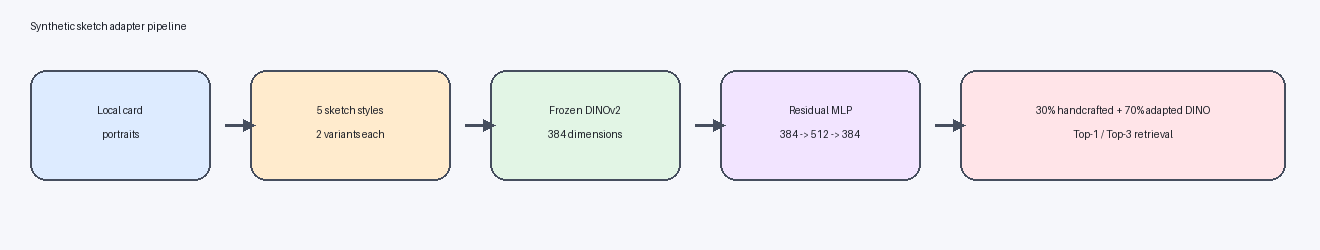

In [2]:
from PIL import Image, ImageDraw

def draw_pipeline_diagram() -> Image.Image:
    image = Image.new("RGB", (1320, 250), (246, 247, 251))
    draw = ImageDraw.Draw(image)
    boxes = [
        (30, 70, 210, 180, "Local card\nportraits", (221, 235, 255)),
        (250, 70, 450, 180, "5 sketch styles\n2 variants each", (255, 235, 205)),
        (490, 70, 680, 180, "Frozen DINOv2\n384 dimensions", (226, 245, 229)),
        (720, 70, 920, 180, "Residual MLP\n384 -> 512 -> 384", (242, 228, 255)),
        (960, 70, 1285, 180, "30% handcrafted + 70% adapted DINO\nTop-1 / Top-3 retrieval", (255, 228, 232)),
    ]
    for left, top, right, bottom, label, color in boxes:
        draw.rounded_rectangle(
            (left, top, right, bottom),
            radius=16,
            fill=color,
            outline=(70, 78, 94),
            width=2,
        )
        parts = label.split("\n")
        y = top + 34
        for part in parts:
            bounds = draw.textbbox((0, 0), part)
            width = bounds[2] - bounds[0]
            draw.text(
                ((left + right - width) / 2, y),
                part,
                fill=(28, 31, 39),
            )
            y += 24
    for x in (225, 465, 695, 935):
        draw.line((x, 125, x + 18, 125), fill=(70, 78, 94), width=3)
        draw.polygon(
            [(x + 18, 119), (x + 30, 125), (x + 18, 131)],
            fill=(70, 78, 94),
        )
    draw.text((30, 20), "Synthetic sketch adapter pipeline", fill=(20, 24, 34))
    return image

pipeline_diagram = draw_pipeline_diagram()
display(pipeline_diagram)

## 2. Synthetic sketch generator

Three styles (`lineart`, `color_edges`, `poster`) are used for optimizer
updates. Two styles (`sparse`, `marker`) are held out from the training
identities and form `val_seen`. Rotation, translation, scale, palette changes,
and random erasing are deterministic from the sample seed.

In [3]:
CANVAS_SIZE = (500, 380)
PAPER_RGB = (244, 238, 220)
PALETTE = (
    (27, 26, 24), (74, 74, 74), (184, 184, 184), (255, 255, 255),
    (122, 75, 42), (210, 166, 106), (127, 29, 45), (217, 58, 58),
    (242, 127, 165), (233, 132, 44), (242, 169, 0), (232, 200, 58),
    PAPER_RGB, (31, 90, 58), (60, 155, 85), (140, 207, 77),
    (56, 197, 201), (36, 74, 141), (54, 123, 211), (114, 183, 232),
    (75, 60, 150), (140, 85, 199), (195, 79, 163), (86, 49, 111),
)
TRAIN_STYLES = ("lineart", "color_edges", "poster")
HELD_OUT_STYLES = ("sparse", "marker")
ALL_STYLES = TRAIN_STYLES + HELD_OUT_STYLES

def _edge_map(image: Image.Image, width: int) -> Image.Image:
    gray = ImageOps.autocontrast(ImageOps.grayscale(image))
    edges = ImageOps.invert(
        ImageOps.autocontrast(gray.filter(ImageFilter.FIND_EDGES))
    )
    edges = edges.point(lambda value: 255 if value > 218 else max(0, value - 40))
    for _ in range(max(0, width - 1)):
        edges = edges.filter(ImageFilter.MinFilter(3))
    return edges

def _palette_image() -> Image.Image:
    palette = Image.new("P", (1, 1))
    flat = [channel for color in PALETTE for channel in color]
    palette.putpalette(flat + [0] * (768 - len(flat)))
    return palette

GAME_PALETTE = _palette_image()

def _quantize(image: Image.Image, colors: int) -> Image.Image:
    return (
        image.convert("RGB")
        .quantize(palette=GAME_PALETTE, dither=Image.Dither.NONE)
        .convert("RGB")
        .quantize(colors=max(2, colors), method=Image.Quantize.FASTOCTREE)
        .convert("RGB")
    )

def _erase_regions(image: Image.Image, rng: random.Random, amount: float) -> None:
    draw = ImageDraw.Draw(image)
    target = image.width * image.height * amount
    erased = 0
    while erased < target:
        width = rng.randint(max(8, image.width // 14), max(12, image.width // 4))
        height = rng.randint(max(8, image.height // 18), max(12, image.height // 4))
        x = rng.randint(-width // 2, image.width - 1)
        y = rng.randint(-height // 2, image.height - 1)
        draw.ellipse((x, y, x + width, y + height), fill=PAPER_RGB)
        erased += width * height

def _fit_to_canvas(image: Image.Image, rng: random.Random) -> Image.Image:
    canvas = Image.new("RGB", CANVAS_SIZE, PAPER_RGB)
    rotated = image.convert("RGB").rotate(
        rng.uniform(-9.0, 9.0),
        resample=Image.Resampling.BICUBIC,
        expand=True,
        fillcolor=PAPER_RGB,
    )
    scale = rng.uniform(0.70, 0.98)
    ratio = min(
        round(CANVAS_SIZE[0] * scale) / rotated.width,
        round(CANVAS_SIZE[1] * scale) / rotated.height,
    )
    resized = rotated.resize(
        (
            max(1, round(rotated.width * ratio)),
            max(1, round(rotated.height * ratio)),
        ),
        Image.Resampling.BICUBIC,
    )
    max_x = max(0, CANVAS_SIZE[0] - resized.width)
    max_y = max(0, CANVAS_SIZE[1] - resized.height)
    x = min(
        max_x,
        max(0, max_x // 2 + rng.randint(-CANVAS_SIZE[0] // 18, CANVAS_SIZE[0] // 18)),
    )
    y = min(
        max_y,
        max(0, max_y // 2 + rng.randint(-CANVAS_SIZE[1] // 18, CANVAS_SIZE[1] // 18)),
    )
    canvas.paste(resized, (x, y))
    return canvas

def render_sketch(portrait: Image.Image, style: str, seed: int) -> Image.Image:
    rng = random.Random(seed)
    source = ImageEnhance.Color(portrait.convert("RGB")).enhance(
        rng.uniform(0.65, 1.25)
    )
    source = ImageEnhance.Contrast(source).enhance(rng.uniform(0.85, 1.35))
    edges = _edge_map(source, rng.choice((1, 1, 2, 2, 3)))

    if style == "lineart":
        result = Image.new("RGB", source.size, rng.choice((PALETTE[0], PALETTE[1], PALETTE[4], PALETTE[16])))
        result.paste(PAPER_RGB, mask=edges)
    elif style == "color_edges":
        colors = _quantize(source, rng.randint(5, 10))
        faded = Image.blend(Image.new("RGB", source.size, PAPER_RGB), colors, rng.uniform(0.42, 0.72))
        result = Image.composite(faded, Image.new("RGB", source.size, rng.choice((PALETTE[0], PALETTE[4], PALETTE[17]))), edges)
    elif style == "poster":
        result = _quantize(source, rng.randint(4, 7))
        result = Image.composite(result, Image.new("RGB", source.size, rng.choice((PALETTE[0], PALETTE[1]))), edges)
        result = result.filter(ImageFilter.SMOOTH)
    elif style == "sparse":
        result = Image.new("RGB", source.size, rng.choice((PALETTE[0], PALETTE[1], PALETTE[7], PALETTE[18])))
        result.paste(PAPER_RGB, mask=edges)
        _erase_regions(result, rng, rng.uniform(0.18, 0.38))
    elif style == "marker":
        result = _quantize(
            ImageEnhance.Color(source).enhance(rng.uniform(1.2, 1.8)),
            rng.randint(3, 6),
        ).filter(ImageFilter.MedianFilter(5))
        result = Image.composite(result, Image.new("RGB", source.size, rng.choice((PALETTE[0], PALETTE[4]))), edges)
        _erase_regions(result, rng, rng.uniform(0.05, 0.16))
    else:
        raise ValueError(f"Unknown style: {style}")

    canvas = _fit_to_canvas(result, rng)
    if rng.random() < 0.75:
        _erase_regions(canvas, rng, rng.uniform(0.02, 0.12))
    return canvas

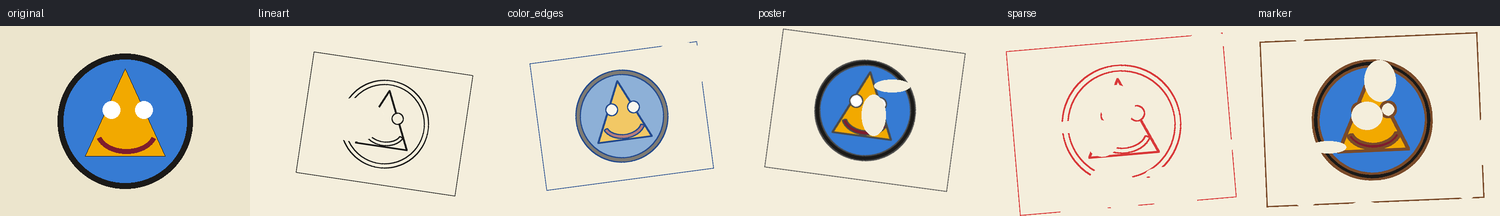

In [4]:
def make_demo_portrait() -> Image.Image:
    image = Image.new("RGB", (500, 380), (236, 229, 205))
    draw = ImageDraw.Draw(image)
    draw.ellipse((115, 55, 385, 325), fill=(54, 123, 211), outline=(27, 26, 24), width=12)
    draw.polygon([(250, 85), (330, 260), (170, 260)], fill=(242, 169, 0), outline=(27, 26, 24))
    draw.ellipse((205, 150, 240, 185), fill=(255, 255, 255))
    draw.ellipse((270, 150, 305, 185), fill=(255, 255, 255))
    draw.arc((190, 165, 315, 255), 20, 160, fill=(127, 29, 45), width=10)
    return image

def make_style_sheet() -> Image.Image:
    original = make_demo_portrait()
    examples = [original] + [
        render_sketch(original, style, SEED + index * 1009)
        for index, style in enumerate(ALL_STYLES)
    ]
    labels = ("original",) + ALL_STYLES
    cell_width, cell_height, header = 250, 190, 26
    sheet = Image.new("RGB", (cell_width * len(examples), cell_height + header), (35, 37, 43))
    draw = ImageDraw.Draw(sheet)
    for index, (label, example) in enumerate(zip(labels, examples, strict=True)):
        thumb = example.copy()
        thumb.thumbnail((cell_width, cell_height), Image.Resampling.LANCZOS)
        tile = Image.new("RGB", (cell_width, cell_height), PAPER_RGB)
        tile.paste(thumb, ((cell_width - thumb.width) // 2, (cell_height - thumb.height) // 2))
        x = index * cell_width
        sheet.paste(tile, (x, header))
        draw.text((x + 8, 7), label, fill=(245, 245, 245))
    return sheet

demo_sheet = make_style_sheet()
display(demo_sheet)

## 3. Card discovery and identity split

The split hashes `seed:card_key`, then reserves 10% of card identities for
`val_zero` and another 10% for `test_zero`. Their positive sketches never
participate in training. Gallery prototypes remain available because inference
is a known-gallery retrieval task.

In [5]:
@dataclass(frozen=True)
class CardRecord:
    index: int
    card_key: str
    card_id: str
    source_path: Path

def discover_cards(card_root: Path) -> list[CardRecord]:
    candidates = []
    for path in card_root.rglob("*.png"):
        relative = path.relative_to(card_root)
        if "beta" in {part.lower() for part in relative.parts}:
            continue
        candidates.append((relative.with_suffix("").as_posix().upper(), path))
    return [
        CardRecord(index, key, path.stem.upper(), path)
        for index, (key, path) in enumerate(sorted(candidates))
    ]

def stable_split(card_keys: list[str], seed: int = SEED) -> dict[str, str]:
    ordered = sorted(
        card_keys,
        key=lambda key: hashlib.sha256(f"{seed}:{key}".encode()).hexdigest(),
    )
    holdout = max(1, round(len(ordered) * 0.10))
    result = {key: "train" for key in ordered}
    for key in ordered[:holdout]:
        result[key] = "val_zero"
    for key in ordered[holdout:holdout * 2]:
        result[key] = "test_zero"
    return result

records = discover_cards(CARD_ROOT) if RUN_FULL_PIPELINE else []
split_by_card = stable_split([record.card_key for record in records])
print(Counter(split_by_card.values()) if records else {
    "reference_train": 485,
    "reference_val_zero": 60,
    "reference_test_zero": 60,
})

{'reference_train': 485, 'reference_val_zero': 60, 'reference_test_zero': 60}


## 4. Frozen DINOv2 embedding cache

The preprocessing matches `Scripts/Ai/DinoArtEmbedder.cs`: resize the shorter
side to 224, center-crop 224×224, apply ImageNet normalization, then L2-normalize
the 384-dimensional DINOv2 output. This cell is the expensive part of a full
reproduction.

In [6]:
def center_crop_input(image: Image.Image):
    import torch

    source = image.convert("RGB")
    scale = max(INPUT_SIZE / source.width, INPUT_SIZE / source.height)
    resized = source.resize(
        (max(1, round(source.width * scale)), max(1, round(source.height * scale))),
        Image.Resampling.BICUBIC,
    )
    left = max(0, (resized.width - INPUT_SIZE) // 2)
    top = max(0, (resized.height - INPUT_SIZE) // 2)
    crop = resized.crop((left, top, left + INPUT_SIZE, top + INPUT_SIZE))
    pixels = np.asarray(crop, dtype=np.float32) / 255.0
    pixels = (
        pixels - np.asarray((0.485, 0.456, 0.406), dtype=np.float32)
    ) / np.asarray((0.229, 0.224, 0.225), dtype=np.float32)
    return torch.from_numpy(pixels.transpose(2, 0, 1).copy())

def load_backbone(device):
    import timm

    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=0,
        img_size=INPUT_SIZE,
    )
    return model.eval().requires_grad_(False).to(device)

def encode_images(model, images, device):
    import torch
    import torch.nn.functional as F

    batch = torch.stack([center_crop_input(image) for image in images]).to(device)
    with torch.inference_mode():
        return F.normalize(model(batch).float(), dim=-1).cpu().numpy().astype(np.float32)

def sample_split(card_split: str, style: str) -> str:
    if card_split == "train" and style in HELD_OUT_STYLES:
        return "val_seen"
    return card_split

def build_embedding_cache(
    records: list[CardRecord],
    split_by_card: dict[str, str],
    output: Path,
    variants_per_style: int = 2,
    batch_size: int = BATCH_SIZE,
):
    import torch

    device = torch.device(
        "mps" if torch.backends.mps.is_available()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )
    model = load_backbone(device)

    portraits = []
    for record in records:
        with Image.open(record.source_path) as image:
            portraits.append(image.convert("RGB").copy())

    prototype_chunks = [
        encode_images(model, portraits[offset:offset + batch_size], device)
        for offset in range(0, len(portraits), batch_size)
    ]
    prototypes = np.concatenate(prototype_chunks)

    embedding_chunks, labels, splits, styles, seeds = [], [], [], [], []
    pending_images, pending_meta = [], []

    def flush():
        if not pending_images:
            return
        embedding_chunks.append(encode_images(model, pending_images, device))
        for label, split, style, sample_seed in pending_meta:
            labels.append(label)
            splits.append(split)
            styles.append(style)
            seeds.append(sample_seed)
        pending_images.clear()
        pending_meta.clear()

    for record, portrait in zip(records, portraits, strict=True):
        for style_index, style in enumerate(ALL_STYLES):
            for variant in range(variants_per_style):
                sample_seed = (
                    SEED + record.index * 100_003 + style_index * 1_009 + variant * 17
                )
                pending_images.append(render_sketch(portrait, style, sample_seed))
                pending_meta.append((
                    record.index,
                    sample_split(split_by_card[record.card_key], style),
                    style,
                    sample_seed,
                ))
                if len(pending_images) >= batch_size:
                    flush()
    flush()

    output.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        output,
        model_name=np.asarray([MODEL_NAME]),
        card_keys=np.asarray([record.card_key for record in records]),
        prototypes=prototypes,
        sketch_embeddings=np.concatenate(embedding_chunks),
        labels=np.asarray(labels, dtype=np.int64),
        splits=np.asarray(splits),
        styles=np.asarray(styles),
        seeds=np.asarray(seeds, dtype=np.int64),
    )
    return output

cache_path = OUTPUT_DIR / "embeddings.npz"
if RUN_FULL_PIPELINE:
    if not CARD_ROOT.is_dir():
        raise FileNotFoundError(f"Set CARD_ROOT to a local portrait directory: {CARD_ROOT}")
    build_embedding_cache(records, split_by_card, cache_path)
else:
    print("Skipped the expensive DINOv2 cache build.")

Skipped the expensive DINOv2 cache build.


## 5. Residual adapter training

The 394,880-parameter adapter is `LayerNorm → Linear(384,512) → GELU →
Dropout(0.10) → Linear(512,384)`, added residually to the input and
L2-normalized. DINOv2 and the gallery prototypes remain frozen.

In [7]:
import torch
import torch.nn.functional as F

class SketchAdapter(torch.nn.Module):
    def __init__(self, dimension=384, hidden_dimension=512, dropout=0.10):
        super().__init__()
        self.dimension = dimension
        self.hidden_dimension = hidden_dimension
        self.dropout = dropout
        self.norm = torch.nn.LayerNorm(dimension)
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(dimension, hidden_dimension),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dimension, dimension),
        )
        torch.nn.init.zeros_(self.mlp[-1].weight)
        torch.nn.init.zeros_(self.mlp[-1].bias)

    def forward(self, embedding):
        normalized = F.normalize(embedding, dim=-1)
        return F.normalize(normalized + self.mlp(self.norm(normalized)), dim=-1)

def compute_metrics(adapter, embeddings, labels, prototypes, batch_size=1024):
    adapter.eval()
    top1 = top3 = 0
    reciprocal_rank = 0.0
    with torch.inference_mode():
        for offset in range(0, len(labels), batch_size):
            x = embeddings[offset:offset + batch_size]
            y = labels[offset:offset + batch_size]
            order = (adapter(x) @ prototypes.T).argsort(dim=1, descending=True)
            top1 += int((order[:, 0] == y).sum())
            top3 += int((order[:, :3] == y[:, None]).any(dim=1).sum())
            ranks = (order == y[:, None]).nonzero(as_tuple=False)[:, 1] + 1
            reciprocal_rank += float((1.0 / ranks.float()).sum())
    count = len(labels)
    return {
        "count": count,
        "top1": top1 / count,
        "top3": top3 / count,
        "mrr": reciprocal_rank / count,
    }

def train_adapter(
    cache_path: Path,
    artifact_dir: Path,
    epochs=40,
    batch_size=256,
    learning_rate=3e-4,
    weight_decay=1e-4,
    temperature=0.07,
    identity_weight=0.01,
    patience=8,
):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    with np.load(cache_path, allow_pickle=False) as cache:
        prototypes = F.normalize(torch.from_numpy(cache["prototypes"].astype(np.float32)), dim=-1)
        embeddings = torch.from_numpy(cache["sketch_embeddings"].astype(np.float32))
        labels = torch.from_numpy(cache["labels"].astype(np.int64))
        split_names = cache["splits"].astype(str)
        card_keys = cache["card_keys"].astype(str).tolist()

    masks = {
        name: torch.from_numpy(split_names == name)
        for name in ("train", "val_seen", "val_zero", "test_zero")
    }
    adapter = SketchAdapter()
    optimizer = torch.optim.AdamW(
        adapter.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, epochs),
    )
    train_indices = masks["train"].nonzero(as_tuple=False).flatten()
    generator = torch.Generator().manual_seed(SEED)
    history, best_score, best_epoch, stale = [], -math.inf, 0, 0
    artifact_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = artifact_dir / "best_adapter.pt"

    for epoch in range(1, epochs + 1):
        adapter.train()
        permutation = train_indices[
            torch.randperm(len(train_indices), generator=generator)
        ]
        total_loss = 0.0
        for offset in range(0, len(permutation), batch_size):
            indices = permutation[offset:offset + batch_size]
            original = F.normalize(embeddings[indices], dim=-1)
            adapted = adapter(embeddings[indices])
            logits = adapted @ prototypes.T / temperature
            loss = (
                F.cross_entropy(logits, labels[indices], label_smoothing=0.02)
                + identity_weight * F.mse_loss(adapted, original)
            )
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach()) * len(indices)
        scheduler.step()

        metrics = {
            name: compute_metrics(
                adapter,
                embeddings[mask],
                labels[mask],
                prototypes,
            )
            for name, mask in masks.items()
            if name in ("val_seen", "val_zero")
        }
        score = (metrics["val_seen"]["top3"] + metrics["val_zero"]["top3"]) / 2
        history.append({
            "epoch": epoch,
            "loss": total_loss / len(train_indices),
            **metrics,
        })
        if score > best_score + 1e-8:
            best_score, best_epoch, stale = score, epoch, 0
            torch.save({
                "state_dict": adapter.state_dict(),
                "dimension": adapter.dimension,
                "hidden_dimension": adapter.hidden_dimension,
                "dropout": adapter.dropout,
                "model_name": MODEL_NAME,
                "card_keys": card_keys,
                "epoch": epoch,
                "selection_score": score,
                "parameter_count": sum(p.numel() for p in adapter.parameters()),
            }, checkpoint_path)
        else:
            stale += 1
            if stale >= patience:
                break

    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    adapter.load_state_dict(checkpoint["state_dict"])
    final_metrics = {
        name: compute_metrics(adapter, embeddings[mask], labels[mask], prototypes)
        for name, mask in masks.items()
    }
    report = {
        "best_epoch": best_epoch,
        "best_adapter": final_metrics,
        "history": history,
    }
    (artifact_dir / "history.json").write_text(
        json.dumps(report, indent=2) + "\n",
        encoding="utf-8",
    )
    return checkpoint_path, report

if RUN_FULL_PIPELINE:
    checkpoint_path, report = train_adapter(cache_path, OUTPUT_DIR)
    print(json.dumps(report["best_adapter"], indent=2))
else:
    print("Skipped training; the reference run selected epoch 15.")

Skipped training; the reference run selected epoch 15.


## 6. Reference holdout comparison

The chart uses `test_zero`: 60 card identities with all five styles and two
variants per style. These are synthetic-domain engineering measurements, not
real-player accuracy.

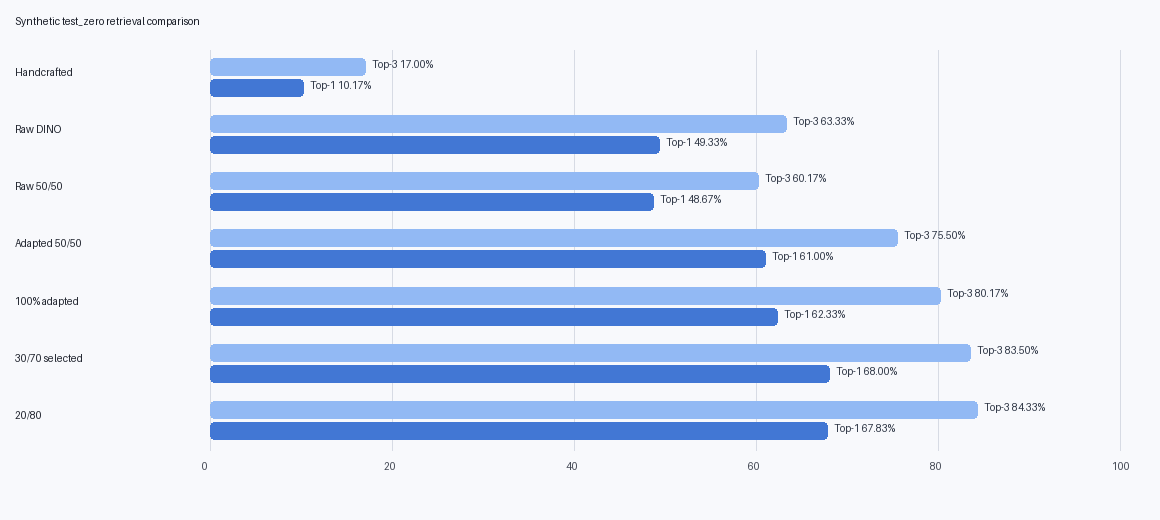

In [8]:
REFERENCE_TEST = {
    "Handcrafted": (10.17, 17.00),
    "Raw DINO": (49.33, 63.33),
    "Raw 50/50": (48.67, 60.17),
    "Adapted 50/50": (61.00, 75.50),
    "100% adapted": (62.33, 80.17),
    "30/70 selected": (68.00, 83.50),
    "20/80": (67.83, 84.33),
}

def draw_metric_chart(metrics: dict[str, tuple[float, float]]) -> Image.Image:
    width, height = 1160, 520
    image = Image.new("RGB", (width, height), (248, 249, 252))
    draw = ImageDraw.Draw(image)
    left, top, bottom = 210, 50, 450
    chart_width = width - left - 40
    chart_height = bottom - top
    for value in range(0, 101, 20):
        x = left + round(chart_width * value / 100)
        draw.line((x, top, x, bottom), fill=(215, 219, 228), width=1)
        draw.text((x - 8, bottom + 10), str(value), fill=(65, 70, 82))
    row_height = chart_height / len(metrics)
    for index, (label, (top1, top3)) in enumerate(metrics.items()):
        y = top + row_height * index + 8
        draw.text((15, y + 8), label, fill=(30, 34, 44))
        top1_width = round(chart_width * top1 / 100)
        top3_width = round(chart_width * top3 / 100)
        draw.rounded_rectangle(
            (left, y, left + top3_width, y + 17),
            radius=4,
            fill=(146, 185, 244),
        )
        draw.rounded_rectangle(
            (left, y + 21, left + top1_width, y + 38),
            radius=4,
            fill=(66, 119, 212),
        )
        draw.text((left + top3_width + 7, y), f"Top-3 {top3:.2f}%", fill=(45, 53, 68))
        draw.text((left + top1_width + 7, y + 21), f"Top-1 {top1:.2f}%", fill=(45, 53, 68))
    draw.text((15, 15), "Synthetic test_zero retrieval comparison", fill=(20, 24, 34))
    return image

metric_chart = draw_metric_chart(REFERENCE_TEST)
display(metric_chart)

## 7. ONNX export and parity verification

The export uses opset 18 with dynamic batch axes. The verification compares
PyTorch and ONNX Runtime for batch sizes 1 and 7 and checks output
normalization.

In [9]:
def export_and_verify(checkpoint_path: Path, output: Path):
    import onnx
    import onnxruntime as ort
    import torch

    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    model = SketchAdapter(
        dimension=int(checkpoint["dimension"]),
        hidden_dimension=int(checkpoint["hidden_dimension"]),
        dropout=float(checkpoint["dropout"]),
    )
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    output.parent.mkdir(parents=True, exist_ok=True)
    example = torch.randn(2, EMBEDDING_SIZE, dtype=torch.float32)
    torch.onnx.export(
        model,
        (example,),
        output,
        input_names=["embedding"],
        output_names=["adapted_embedding"],
        dynamic_axes={
            "embedding": {0: "batch"},
            "adapted_embedding": {0: "batch"},
        },
        opset_version=18,
        dynamo=False,
    )
    onnx.checker.check_model(onnx.load(output))
    session = ort.InferenceSession(str(output), providers=["CPUExecutionProvider"])
    rng = np.random.default_rng(SEED)
    checks = {}
    for batch_size in (1, 7):
        input_array = rng.standard_normal((batch_size, EMBEDDING_SIZE)).astype(np.float32)
        with torch.inference_mode():
            expected = model(torch.from_numpy(input_array)).numpy()
        actual = session.run(["adapted_embedding"], {"embedding": input_array})[0]
        checks[batch_size] = {
            "max_absolute_error": float(np.max(np.abs(actual - expected))),
            "minimum_cosine": float(np.min(np.sum(actual * expected, axis=1))),
            "maximum_norm_error": float(
                np.max(np.abs(np.linalg.norm(actual, axis=1) - 1.0))
            ),
        }
    return checks

if RUN_FULL_PIPELINE:
    checks = export_and_verify(
        OUTPUT_DIR / "best_adapter.pt",
        OUTPUT_DIR / "sketch_adapter.onnx",
    )
    print(json.dumps(checks, indent=2))
else:
    print({
        "reference_sha256": "4f99320d3a12cc6b164446dd3fbc02ac532c1bc7a4cc3ad81cee84372290ac13",
        "opset": 18,
        "input": "embedding [batch, 384]",
        "output": "adapted_embedding [batch, 384]",
    })

{'reference_sha256': '4f99320d3a12cc6b164446dd3fbc02ac532c1bc7a4cc3ad81cee84372290ac13', 'opset': 18, 'input': 'embedding [batch, 384]', 'output': 'adapted_embedding [batch, 384]'}


## Limitations

- Synthetic sketches remain more directly related to card art than real human
  drawings.
- The next meaningful validation set should contain consented drawings split
  by artist.
- Different game versions or modded card pools can change the gallery.
- Do not commit generated images, local paths, embedding caches, checkpoints,
  or game assets.

See `docs/sketch-adapter-training.md` for the complete experiment writeup and
all Top-1/Top-3 tables.